NumPy, short for Numerical Python, is one of the most important foundational packages
for numerical computing in Python. Most computational packages providing
scientific functionality use NumPy’s array objects as the lingua franca for data
exchange.

Some Functionalities : 

* ndarray, an efficient multidimensional array providing fast array-oriented arithmetic operations and flexible broadcasting capabilities.
* Mathematical functions for fast operations on entire arrays of data without having
to write loops.
*Tools for reading/writing array data to disk and working with memory-mapped
files.
* Linear algebra, random number generation, and Fourier transform capabilities.
* A C API for connecting NumPy with libraries written in C, C++, or FORTRAN.

One of the reasons NumPy is so important for numerical computations in Python is
because it is designed for efficiency on large arrays of data. There are a number of
reasons for this:

• NumPy internally stores data in a contiguous block of memory, independent of
other built-in Python objects. NumPy’s library of algorithms written in the C language
can operate on this memory without any type checking or other overhead.
NumPy arrays also use much less memory than built-in Python sequences.

• NumPy operations perform complex computations on entire arrays without the
need for Python for loops.
86

In [1]:
import numpy as np

In [2]:
my_arr = np.arange(1000000)

In [3]:
my_list = list(range(1000000))

In [4]:
print(my_arr)

[     0      1      2 ... 999997 999998 999999]


In [5]:
print(my_list)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [6]:
%time for _ in range(10): my_arr2 = my_arr * 2

CPU times: total: 0 ns
Wall time: 19.9 ms


In [7]:
%time for _ in range(10): my_list2 = [x * 2 for x in my_list]

CPU times: total: 297 ms
Wall time: 471 ms


NumPy-based algorithms are generally 10 to 100 times faster (or more) than their
pure Python counterparts and use significantly less memory.

# 4.1 The NumPy ndarray: A Multidimensional Array Object

One of the key features of NumPy is its N-dimensional array object, or ndarray,
which is a fast, flexible container for large datasets in Python. Arrays enable you to
perform mathematical operations on whole blocks of data using similar syntax to the
equivalent operations between scalar elements.

In [8]:
data = np.random.randn(2, 3)

In [9]:
data

array([[ 0.11904188,  1.09126076, -0.78501889],
       [ 0.12418011,  0.25986792,  0.25362607]])

In [10]:
data*10

array([[ 1.19041878, 10.91260762, -7.85018892],
       [ 1.24180111,  2.59867917,  2.5362607 ]])

In [11]:
data+data

array([[ 0.23808376,  2.18252152, -1.57003778],
       [ 0.24836022,  0.51973583,  0.50725214]])

In this chapter and throughout the book, I use the standard
NumPy convention of always using import numpy as np. You are,
of course, welcome to put from numpy import * in your code to
avoid having to write np., but I advise against making a habit of
this. The numpy namespace is large and contains a number of functions
whose names conflict with built-in Python functions (like min
and max).

**An ndarray is a generic multidimensional container for homogeneous data**

In [12]:
data.shape

(2, 3)

In [13]:
data2 = [[1, 2, 3, 4], [5, 6, 7, 8]]

In [14]:
arr2 = np.array(data2)

In [15]:
arr2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [16]:
arr2.shape


(2, 4)

In [17]:
arr2.ndim

2

**Data Type**

In [18]:
arr2.dtype

dtype('int64')

In [19]:
data.dtype

dtype('float64')

**zeros and ones and empty**

np.zeros(10)

In [20]:
np.zeros((3, 6))

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [21]:
np.ones((3, 4))

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [22]:
np.ones((3, 4,2))

array([[[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]])

In [23]:
np.empty((2, 3, 2))

array([[[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]]])

It’s not safe to assume that np.empty will return an array of all
zeros. In some cases, it may return uninitialized “garbage” values

In [24]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [25]:
np.identity(5)

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [26]:
np.ones_like(arr2)

array([[1, 1, 1, 1],
       [1, 1, 1, 1]])

In [27]:
np.full((3,3), 23, 'float64')

array([[23., 23., 23.],
       [23., 23., 23.],
       [23., 23., 23.]])

<img src="functions_in_np.jpg" width="500" height="300" />

----

#### Data Types for ndarrays

The data type or dtype is a special object containing the information (or metadata,
data about data) the ndarray needs to interpret a chunk of memory as a particular
type of data:

In [30]:
# You can specify the data type.
arr1 = np.array([1, 2, 3], dtype=np.float64)
arr2 = np.array([1, 2, 3], dtype=np.int32)

In [31]:
arr2.dtype

dtype('int32')

In [32]:
arr1.dtype

dtype('float64')

In [33]:
arr3 = np.array(['1', 2, 3])

In [34]:
arr3.dtype

dtype('<U21')

In [35]:
arr4 = np.array([1, 2, 3])
arr4.dtype

dtype('int64')


You wrote:

```python
arr3 = np.array(['1', 2, 3])
arr3.dtype
```

Output:

```
dtype('<U21')
```

Let’s decode this properly.

---

# 🔎 What Does `<U21` Mean?

`<U21` is NumPy’s way of describing a **fixed-length Unicode string type**.

It has three parts:

```
<   U   21
│   │    │
│   │    └── Maximum number of characters
│   └──────── Unicode string
└──────────── Little-endian byte order
```

So:

> `<U21` = Little-endian Unicode string with maximum length 21 characters per element.

---

# 🧠 Why Did NumPy Choose String Type?

You passed:

```python
['1', 2, 3]
```

There is a string `'1'` inside the list.

NumPy arrays must be **homogeneous** (same dtype for all elements).

So NumPy promotes everything to the **most general compatible type**.

Type hierarchy (simplified):

```
int  → float → complex
int  → string
float → string
```

Since you included a string:

```
int + string → string
```

So 2 and 3 became:

```
'2'
'3'
```

Now the array is:

```python
['1', '2', '3']
```

---

# 📏 Why 21 Characters?

NumPy determines the **maximum string length needed** among all elements.

Internally:

* It converts everything to string
* Finds the longest string
* Allocates fixed width for all elements

Example:

```python
np.array(['short', 'veryverylongstring'])
```

Would produce something like:

```
<U18
```

Because the longest string has 18 characters.

---

# 🏗 Important Architecture Concept

Unlike Python strings (variable-length objects), NumPy strings are:

* Fixed-length
* Stored in contiguous memory
* Zero-padded internally

Each element in `<U21`:

* Uses 21 Unicode characters
* Each Unicode character = 4 bytes (UTF-32 internally)

So memory per element:

```
21 × 4 bytes = 84 bytes
```

Even if the string is just `'1'`.

This is why string arrays in NumPy are often memory inefficient.

---

# 🧮 Compare Memory

```python
arr3.itemsize
```

You’ll see:

```
84
```

While:

```python
arr2.itemsize
```

Was:

```
4
```

Huge difference.

---

# ⚠ Important Data Science Insight

NumPy string arrays are rarely ideal for:

* Text processing
* NLP
* Large categorical data

Why?

* Fixed-width
* Memory heavy
* No vectorized string intelligence (limited)

That’s why in real systems:

* Use Pandas `object` dtype
* Or Pandas `string` dtype
* Or Categorical type

---

# 🔬 Quick Experiment

```python
arr3
```

Will show:

```python
array(['1', '2', '3'], dtype='<U21')
```

Everything became string.

---

# 🎯 Key Takeaway

`<U21` means:

> Fixed-width Unicode string type with capacity of 21 characters per element, stored in little-endian format.

And it happened because NumPy had to promote mixed types to a single common dtype.

---

If you want, next we can go deeper into:

* Why NumPy uses fixed-width strings instead of variable length
* Difference between `<U`, `|S`, and `object`
* How Pandas handles strings differently
* Or how dtype promotion rules work internally

What direction should we explore?


> Don’t worry about memorizing the NumPy dtypes, especially if
you’re a new user. It’s often only necessary to care about the general
kind of data you’re dealing with, whether floating point, complex,
integer, boolean, string, or general Python object. When you need
more control over how data are stored in memory and on disk,
especially large datasets, it is good to know that you have control
over the storage type.

> # 🚨
> **Watch Out!** It’s important to be cautious when using the numpy.string_ type,
as string data in NumPy is fixed size and may truncate input
without warning. pandas has more intuitive out-of-the-box behavior
on non-numeric data.

### Casting

In [39]:
arr = np.array([1, 2, 3, 4, 5])
arr.dtype

dtype('int64')

In [40]:
float_arr = arr.astype(np.float64)
float_arr.dtype

dtype('float64')

In [41]:
arr= arr.astype(np.float64)

In [42]:
arr.dtype

dtype('float64')

In [43]:
arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
arr

array([ 3.7, -1.2, -2.6,  0.5, 12.9, 10.1])

In [44]:
arr.astype(np.int32)

array([ 3, -1, -2,  0, 12, 10], dtype=int32)

**If casting were to fail for some reason (like a string that cannot be converted to
float64), a ValueError will be raised** 

In [48]:
numeric_strings = np.array(['1.25', '-9.6ABCD', '42'])

In [49]:
numeric_strings.dtype

dtype('<U8')

In [52]:
numeric_strings.astype(float)

ValueError: could not convert string to float: np.str_('-9.6ABCD')

**You can also use another array’s dtype attribute:**

In [53]:
int_array = np.arange(10)

In [54]:
calibers = np.array([.22, .270, .357, .380, .44, .50], dtype=np.float64)

In [55]:
int_array.astype(calibers.dtype)

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

**Shorthand for Data types**

In [56]:
empty_uint32 = np.empty(8, dtype='u4')

In [57]:
empty_uint32

array([0, 0, 0, 0, 0, 0, 0, 0], dtype=uint32)


---

# 🔎 What Does `'u4'` Mean?

`'u4'` is NumPy’s compact dtype string notation.

It breaks down like this:

```
u   4
│   │
│   └── 4 bytes
└──────── unsigned integer
```

So:

> `'u4'` = unsigned 4-byte integer = `np.uint32`

---

# ✅ Equivalent Forms

All of these are identical:

```python
dtype='u4'
dtype=np.uint32
dtype='uint32'
dtype('u4')
```

You can verify:

```python
empty_uint32.dtype
```

Output:

```
dtype('uint32')
```

---

# 🧠 Why 4 Bytes?

4 bytes = 32 bits

Unsigned 32-bit integer:

* Minimum: 0
* Maximum: 4,294,967,295 (2³² − 1)

No negative numbers allowed.

---

# 🏗 Memory-Level View

```python
np.empty(8, dtype='u4')
```

Means:

* 8 elements
* Each element = 4 bytes
* Total memory = 32 bytes

Memory layout:

```
[____][____][____][____][____][____][____][____]
 4B    4B    4B    4B    4B    4B    4B    4B
```

Since you used `np.empty`, values are **uninitialized** (whatever was in memory).

---

# 📘 Common NumPy Type Codes

| Code    | Meaning        | Bytes |
| ------- | -------------- | ----- |
| `'i4'`  | signed int32   | 4     |
| `'i8'`  | signed int64   | 8     |
| `'u4'`  | unsigned int32 | 4     |
| `'u8'`  | unsigned int64 | 8     |
| `'f4'`  | float32        | 4     |
| `'f8'`  | float64        | 8     |
| `'c16'` | complex128     | 16    |

So pattern is:

```
<type><bytes>
```

---

# ⚠ Signed vs Unsigned Difference

```python
np.array([-1], dtype='i4')
```

Works.

```python
np.array([-1], dtype='u4')
```

Will wrap around:

```
4294967295
```

Because unsigned cannot represent negatives.

This is called **integer underflow**.

---

# 🎯 Why This Matters in Data Science

Choosing unsigned vs signed:

* Saves memory
* Prevents negative values
* Important in:

  * Image processing (pixel values 0–255 → `u1`)
  * Hashing
  * Bit operations
  * Large IDs

Example:

Images typically use:

```python
dtype='u1'
```

Which is unsigned 1-byte (0–255).

---

# 🏛 Architect-Level Insight

NumPy dtype system mirrors C types:

```
u4 → uint32_t
i4 → int32_t
f8 → double
```

That’s why NumPy integrates efficiently with:

* C
* C++
* Fortran
* BLAS
* LAPACK

---

# 🔥 Final Summary

`'u4'` means:

> Unsigned 4-byte integer → `np.uint32`

It’s a compact, C-style dtype descriptor used internally by NumPy.

---

If you'd like, next we can explore:

* Endianness notation (`<`, `>`, `|`)
* Structured dtypes
* How dtype impacts overflow behavior
* Or how NumPy maps dtypes to C under the hood

Where shall we go deeper?


### Arithmetic with NumPy Arrays - Vectorization

Arrays are important because they enable you to express batch operations on data
without writing any for loops. NumPy users call this vectorization. Any arithmetic
operations between equal-size arrays applies the operation element-wise:

In [58]:
arr = np.array([[1., 2., 3.], [4., 5., 6.]])
arr * arr

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

-----
Arithmetic operations with scalars propagate the scalar argument to each element in
the array:

In [59]:
1 / arr

array([[1.        , 0.5       , 0.33333333],
       [0.25      , 0.2       , 0.16666667]])

In [60]:
arr ** 0.5

array([[1.        , 1.41421356, 1.73205081],
       [2.        , 2.23606798, 2.44948974]])

--------
Comparisons between arrays of the same size yield boolean arrays:

In [61]:
arr = np.array([[1., 2., 3.], [4., 5., 6.]])
arr2 = np.array([[0., 4., 1.], [7., 2., 12.]])

arr>arr2

array([[ True, False,  True],
       [False,  True, False]])

-----
### Basic Indexing and Slicing

In [64]:
arr = np.arange(10)

In [65]:
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [66]:
arr[5:9]

array([5, 6, 7, 8])

------
if you assign a scalar value to a slice, as in arr[5:8] = 12, the value is
propagated (or broadcasted henceforth) to the entire selection.

In [67]:
arr[5:9] =  139
arr

array([  0,   1,   2,   3,   4, 139, 139, 139, 139,   9])

----
# 🚨 
### Numpy do not copy slices. Be careful!!!
> An important first distinction from Python’s built-in lists is that array slices are views on the original array.
This means that the data is not copied, and any modifications to the view will be
reflected in the source array.

In [71]:
arr=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
arr_slice = arr[5:8]

In [72]:
arr_slice[1] = 12345
print(arr_slice)
print(arr)

[    5 12345     7]
[    0     1     2     3     4     5 12345     7     8     9]


**If you want a copy of a slice of an ndarray instead of a view, you will need to explicitly copy the array—for example, arr[5:8].copy().**

In [73]:
arr=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
arr_slice = arr[5:8].copy()
arr_slice[1] = 123456789
print(arr_slice)
print(arr)

[        5 123456789         7]
[0 1 2 3 4 5 6 7 8 9]


----

### Multidimentioanl Arrays

In multidimensional arrays, if you omit later indices, the returned object will be a
lower dimensional ndarray consisting of all the data along the higher dimensions. So
in the 2 × 2 × 3 array arr3d:

In [75]:
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])

In [76]:
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [77]:
arr3d[0]

array([[1, 2, 3],
       [4, 5, 6]])

In [78]:
arr3d[0][1]

array([4, 5, 6])

In [80]:
arr3d[0][1][2]

np.int64(6)

----

In [ ]:
old_values = arr3d[0].copy()

In [82]:
arr3d[0] = 42

In [83]:
arr3d

array([[[42, 42, 42],
        [42, 42, 42]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [85]:
arr3d[0] = old_values 
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

-----
### N Dimenational Array Slicing

In [86]:
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [87]:
# One Dimensional  slicing : 
arr[1:6]

array([1, 2, 3, 4, 5])

In [91]:
## Two Dimensional
arr2d = np.array([[1, 2, 3],
[4, 5, 6],
[7, 8, 9]])

**Now  first slice [] will be fore rows.**

In [92]:
arr2d[1]

array([4, 5, 6])

In [93]:
arr2d[0]

array([1, 2, 3])

**With in first [] if you use : it will take part one or more rows.**

In [95]:
arr2d[0:1]

array([[1, 2, 3]])

In [96]:
arr2d[0:2]  # First row (row num 0) and Secodn row ( row num 1)

array([[1, 2, 3],
       [4, 5, 6]])

In [97]:
arr2d[:2]

array([[1, 2, 3],
       [4, 5, 6]])

In [98]:
arr2d[:]

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

**Second slice [] will be columsns**


In [101]:
arr2d[:2,    1:]  # Read this way --> Take rows 0 and 1 and  column 1 onwards.

array([[2, 3],
       [5, 6]])

In [102]:
arr2d[1, :2]

array([4, 5])

In [103]:
arr2d[:2, 2]

array([3, 6])

In [104]:
arr2d[:2, 1:] = 0

In [105]:
arr2d

array([[1, 0, 0],
       [4, 0, 0],
       [7, 8, 9]])

----
### Boolean Indexing

In [106]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
data = np.random.randn(7, 4)
data

array([[ 0.63749322, -0.22373658, -0.81771878,  0.31220756],
       [ 0.31870603,  0.10483447,  0.41839624,  0.30015655],
       [-0.35400742, -0.63320279,  0.78665446,  0.88484455],
       [ 0.86565912, -0.92869669,  0.71377581, -0.89668375],
       [ 0.32313646, -0.75756684,  0.83067265,  0.32292538],
       [-2.00015562, -1.0423662 ,  0.91154745, -0.0701075 ],
       [-0.77345803, -0.22814335,  2.89446538, -1.45179496]])

In [107]:
names == 'Bob'

array([ True, False, False,  True, False, False, False])

Now I can use this to select rows from data where name is == Bob

In [108]:
data[names == 'Bob']

array([[ 0.63749322, -0.22373658, -0.81771878,  0.31220756],
       [ 0.86565912, -0.92869669,  0.71377581, -0.89668375]])

1st and 4th row returned.

In [109]:
data[names == 'Bob', 2:]  # will give all columsn from 3rd column for same data

array([[-0.81771878,  0.31220756],
       [ 0.71377581, -0.89668375]])

In [111]:
data [names !="Bob"]

array([[ 0.31870603,  0.10483447,  0.41839624,  0.30015655],
       [-0.35400742, -0.63320279,  0.78665446,  0.88484455],
       [ 0.32313646, -0.75756684,  0.83067265,  0.32292538],
       [-2.00015562, -1.0423662 ,  0.91154745, -0.0701075 ],
       [-0.77345803, -0.22814335,  2.89446538, -1.45179496]])

In [113]:
# Same values by ~ negation.
data[~(names == 'Bob')]

array([[ 0.31870603,  0.10483447,  0.41839624,  0.30015655],
       [-0.35400742, -0.63320279,  0.78665446,  0.88484455],
       [ 0.32313646, -0.75756684,  0.83067265,  0.32292538],
       [-2.00015562, -1.0423662 ,  0.91154745, -0.0701075 ],
       [-0.77345803, -0.22814335,  2.89446538, -1.45179496]])

In [114]:
cond = names == 'Bob'

In [115]:
data[~cond]

array([[ 0.31870603,  0.10483447,  0.41839624,  0.30015655],
       [-0.35400742, -0.63320279,  0.78665446,  0.88484455],
       [ 0.32313646, -0.75756684,  0.83067265,  0.32292538],
       [-2.00015562, -1.0423662 ,  0.91154745, -0.0701075 ],
       [-0.77345803, -0.22814335,  2.89446538, -1.45179496]])

In [116]:
mask = (names == 'Bob') | (names == 'Will')

**Selecting data from an array by boolean indexing always creates a copy of the data,
even if the returned array is unchanged.**

In [117]:
data[data < 0] = 0  # This will set all values less than 0 to 0 in Data array

In [118]:
data

array([[0.63749322, 0.        , 0.        , 0.31220756],
       [0.31870603, 0.10483447, 0.41839624, 0.30015655],
       [0.        , 0.        , 0.78665446, 0.88484455],
       [0.86565912, 0.        , 0.71377581, 0.        ],
       [0.32313646, 0.        , 0.83067265, 0.32292538],
       [0.        , 0.        , 0.91154745, 0.        ],
       [0.        , 0.        , 2.89446538, 0.        ]])

----

### Fancy Indexing

Fancy indexing is a term adopted by NumPy to describe indexing using integer arrays.

In [121]:
arr = np.empty((8, 4))
for i in range(8):
    arr[i] = i

arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

In [123]:
arr[[4, 3, 0, 6]] # this is is fancy indexing.  the rows mentioned in one dimenstional array are used to select respective rows in this case. 

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

In [127]:
arr[[-3, -5, -7]] # From last row picks if negative

array([[5., 5., 5., 5.],
       [3., 3., 3., 3.],
       [1., 1., 1., 1.]])

In [129]:
# Create a oen dimensioanla rray of 0 -31 and then moake it 8 rows 4 columns
arr = np.arange(32).reshape((8, 4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [130]:
arr[[1, 5, 7, 2], [0, 3, 1, 2]]

array([ 4, 23, 29, 10])

In [131]:
# this gave a single dimentions array by pick the combinations of rows and columns : (1, 0), (5, 3), (7, 1), and (2, 2)

In [132]:
# Mye xpectation was a 2 diemsntioanl arrayw ith rows 1, 5, 7, 2 and columns : 0, 3, 1, 2

In [134]:
arr[[1, 5, 7, 2]] [:,[0, 3, 1, 2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

----
### Transposing Arrays and Swapping Axes


When people say **“dot of matrices”**, they usually mean:

> **Matrix multiplication (dot product of two matrices)**

Let’s build it clearly and correctly.

---

# 1️⃣ Dot Product (Vector Case First)

Before matrices, understand vectors.

If:

```
a = [1, 2, 3]
b = [4, 5, 6]
```

Dot product:

```
a · b = (1×4) + (2×5) + (3×6)
      = 4 + 10 + 18
      = 32
```

So:

> Dot product = multiply corresponding elements, then sum.

---

# 2️⃣ Matrix Dot Product (Matrix Multiplication)

Now extend this idea to matrices.

If:

```
A is (m × n)
B is (n × p)
```

Then:

```
A · B is (m × p)
```

⚠ Important rule:

> Number of columns in A must equal number of rows in B.

---

# 3️⃣ How It Actually Works

Each element in the result is:

> Dot product of one row of A with one column of B.

---

### Example

Let:

```
A = | 1  2 |
    | 3  4 |

B = | 5  6 |
    | 7  8 |
```

To compute:

```
C = A · B
```

Take row 1 of A and column 1 of B:

```
(1×5) + (2×7) = 5 + 14 = 19
```

Row 1 and column 2:

```
(1×6) + (2×8) = 6 + 16 = 22
```

Row 2 and column 1:

```
(3×5) + (4×7) = 15 + 28 = 43
```

Row 2 and column 2:

```
(3×6) + (4×8) = 18 + 32 = 50
```

Result:

```
C = | 19  22 |
    | 43  50 |
```

---

# 4️⃣ In NumPy

```python
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

np.dot(A, B)
```

OR (modern preferred):

```python
A @ B
```

Both give:

```
array([[19, 22],
       [43, 50]])
```

---

# 5️⃣ Important: Dot ≠ Elementwise Multiply

This:

```python
A * B
```

Gives:

```
[[ 5 12]
 [21 32]]
```

That is element-wise multiplication.

But:

```python
A @ B
```

Is matrix multiplication.

Very different operations.

---

# 6️⃣ Why Dot Product Matters in Data Science

Almost everything in ML is matrix multiplication:

* Linear regression:

  ```
  y = XW
  ```
* Neural networks:

  ```
  Z = XW + b
  ```
* PCA
* SVD
* Attention in Transformers

Underneath:

> Everything reduces to repeated dot products.

---

# 7️⃣ Geometric Meaning (Deep Insight)

For vectors:

```
a · b = |a||b| cosθ
```

Meaning:

* Measures alignment
* If dot = 0 → perpendicular
* Large positive → similar direction
* Negative → opposite direction

This is why dot product is used in:

* Cosine similarity
* Recommendation systems
* NLP embeddings

---

# 🔥 Architect-Level View

Matrix multiplication is:

> A transformation composition.

If:

* Matrix A = transformation 1
* Matrix B = transformation 2

Then:

```
A · B
```

Means apply B first, then A.

It’s function composition in linear algebra form.

---

# 🎯 Final Summary

Matrix dot product:

* Multiply row of first matrix with column of second
* Sum the products
* Requires shape compatibility
* Produces a new matrix
* Backbone of machine learning

---

If you want, next we can explore:

* Why matrix multiplication is not commutative
* How BLAS optimizes dot operations
* How GPUs accelerate dot products
* Or geometric visualization of matrix multiplication

Which direction would you like?


In [135]:
arr = np.arange(15).reshape((3, 5))
arr

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [136]:
arr.T

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

In [139]:
arr = np.random.randn(6, 3)
arr

array([[-1.02535957,  0.58661465,  0.21505116],
       [ 0.20387665,  0.21982385, -0.55200222],
       [ 0.46883015,  0.26238337, -1.08379234],
       [-1.1779507 , -1.0357653 , -0.90625056],
       [-1.24986626,  1.42121188, -1.75558794],
       [-1.27454603, -0.2340526 , -0.40881375]])

In [138]:
aee

NameError: name 'aee' is not defined

In [140]:
np.dot(arr.T, arr)

array([[ 5.88693074, -0.69159427,  2.94166091],
       [-0.69159427,  3.6087179 , -1.7402758 ],
       [ 2.94166091, -1.7402758 ,  5.59606708]])

---
### Universal Functions: Fast Element-Wise Array Functions

A universal function, or ufunc, is a function that performs element-wise operations
on data in ndarrays. You can think of them as fast vectorized wrappers for simple
functions that take one or more scalar values and produce one or more scalar results.

In [142]:
arr = np.arange(10)
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [143]:
np.sqrt(arr)

array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

In [144]:
np.exp(arr)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

----
These are referred to as unary ufuncs. Others, such as add or maximum, take two arrays
(thus, binary ufuncs) and return a single array as the result:

In [146]:
x = np.random.randn(8)

In [147]:
y = np.random.randn(8)

In [148]:
x

array([-0.40787599, -1.84525947, -0.45128128,  1.35488675,  0.52947811,
       -0.05295779, -0.34427106,  1.42222121])

In [149]:
y

array([ 0.90799826, -0.72173559,  0.6154004 , -1.63414874, -1.31362922,
        1.08829619,  0.24654089, -1.56860802])

In [150]:
np.maximum(x, y)

array([ 0.90799826, -0.72173559,  0.6154004 ,  1.35488675,  0.52947811,
        1.08829619,  0.24654089,  1.42222121])

-------

While not common, a ufunc can return multiple arrays. modf is one example, a vectorized
version of the built-in Python divmod; it returns the fractional and integral
parts of a floating-point array:

In [152]:
arr = np.random.randn(7) * 5

In [153]:
arr

array([ 2.47458057, -3.99957069,  4.09704886,  1.35987966, -1.45210378,
        0.47499148, -4.22483791])

In [154]:
remainder, whole_part = np.modf(arr)

In [155]:
remainder

array([ 0.47458057, -0.99957069,  0.09704886,  0.35987966, -0.45210378,
        0.47499148, -0.22483791])

In [156]:
whole_part 

array([ 2., -3.,  4.,  1., -1.,  0., -4.])

----------------------------------
Ufuncs accept an optional out argument that allows them to operate in-place on arrays:

In [157]:
arr

array([ 2.47458057, -3.99957069,  4.09704886,  1.35987966, -1.45210378,
        0.47499148, -4.22483791])

In [158]:
np.sqrt(arr)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_13968\2296558006.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(arr)


array([1.57307996,        nan, 2.02411681, 1.16613878,        nan,
       0.68919626,        nan])

In [159]:
np.sqrt(arr, arr)

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_13968\269955669.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(arr, arr)


array([1.57307996,        nan, 2.02411681, 1.16613878,        nan,
       0.68919626,        nan])

In [160]:
arr

array([1.57307996,        nan, 2.02411681, 1.16613878,        nan,
       0.68919626,        nan])

---

### Listing of available ufuncs.

<img src="ufuncs.jpg" width="500" height="300" />

### Array-Oriented Programming with Arrays

**Verctorization** : practice of replacing explicit loops with array expressions

In general, vectorized array operations will often be one or two (or more) orders
of magnitude faster than their pure Python equivalents, with the biggest impact in
any kind of numerical computations.

In [165]:
points = np.arange(-5, 5, 0.01) # 1000 equally spaced points
points

array([-5.0000000e+00, -4.9900000e+00, -4.9800000e+00, -4.9700000e+00,
       -4.9600000e+00, -4.9500000e+00, -4.9400000e+00, -4.9300000e+00,
       -4.9200000e+00, -4.9100000e+00, -4.9000000e+00, -4.8900000e+00,
       -4.8800000e+00, -4.8700000e+00, -4.8600000e+00, -4.8500000e+00,
       -4.8400000e+00, -4.8300000e+00, -4.8200000e+00, -4.8100000e+00,
       -4.8000000e+00, -4.7900000e+00, -4.7800000e+00, -4.7700000e+00,
       -4.7600000e+00, -4.7500000e+00, -4.7400000e+00, -4.7300000e+00,
       -4.7200000e+00, -4.7100000e+00, -4.7000000e+00, -4.6900000e+00,
       -4.6800000e+00, -4.6700000e+00, -4.6600000e+00, -4.6500000e+00,
       -4.6400000e+00, -4.6300000e+00, -4.6200000e+00, -4.6100000e+00,
       -4.6000000e+00, -4.5900000e+00, -4.5800000e+00, -4.5700000e+00,
       -4.5600000e+00, -4.5500000e+00, -4.5400000e+00, -4.5300000e+00,
       -4.5200000e+00, -4.5100000e+00, -4.5000000e+00, -4.4900000e+00,
       -4.4800000e+00, -4.4700000e+00, -4.4600000e+00, -4.4500000e+00,
      

In [166]:
xs, ys = np.meshgrid(points, points)

In [167]:
xs

array([[-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       ...,
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99]],
      shape=(1000, 1000))

In [168]:
ys

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]],
      shape=(1000, 1000))

In [169]:
z = np.sqrt(xs ** 2 + ys ** 2)

In [170]:
z

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985,
        7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603,
        7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568]], shape=(1000, 1000))

In [171]:
import matplotlib.pyplot as plt

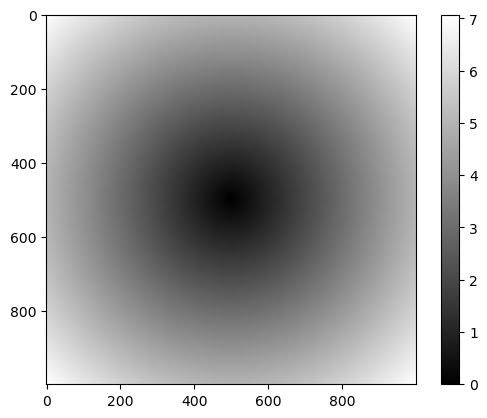

In [172]:
plt.imshow(z, cmap=plt.cm.gray); plt.colorbar()

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

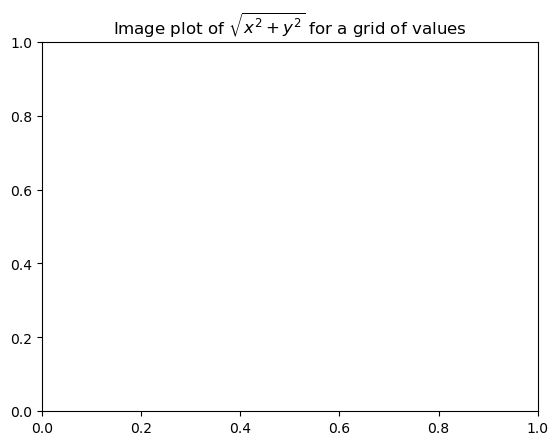

In [173]:
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

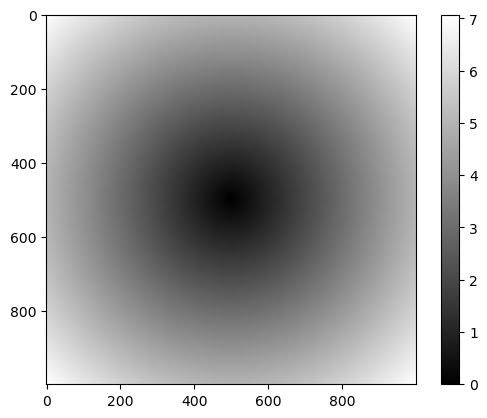

In [174]:
plt.imshow(z, cmap=plt.cm.gray); plt.colorbar()

#### Expressing Conditional Logic as Array Operations

In [175]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])


Suppose we wanted to take a value from xarr whenever the corresponding value in
cond is True, and otherwise take the value from yarr. A list comprehension doing
this might look like :

In [178]:
result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]

In [179]:
result

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

This has multiple problems. First, it will not be very fast for large arrays (because all
the work is being done in interpreted Python code). Second, it will not work with
multidimensional arrays. With np.where you can write this very concisely:

In [181]:
result = np.where(cond, xarr, yarr)

In [182]:
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

The second and third arguments to np.where don’t need to be arrays; one or both of
them can be scalars. A typical use of where in data analysis is to produce a new array
of values based on another array. Suppose you had a matrix of randomly generated
data and you wanted to replace all positive values with 2 and all negative values with
–2. This is very easy to do with np.where

In [183]:
arr = np.random.randn(4, 4)

In [184]:
arr

array([[ 8.61521895e-03, -1.66504824e+00, -7.11011911e-01,
         3.96879641e-01],
       [ 1.95030685e-03,  2.18311957e+00, -1.49424834e+00,
        -1.43864083e+00],
       [ 2.04590597e-01,  1.92299645e+00,  3.64288715e-01,
        -5.43879170e-01],
       [ 4.69215206e-01,  4.39825784e-01, -5.93580014e-01,
         2.07818337e+00]])

In [185]:
np.where(arr > 0, 2, -2)

array([[ 2, -2, -2,  2],
       [ 2,  2, -2, -2],
       [ 2,  2,  2, -2],
       [ 2,  2, -2,  2]])

You can combine scalars and arrays when using np.where. For example, I can replace
all positive values in arr with the constant 2 like so:

In [186]:
np.where(arr > 0, 2, arr) # set only positive values to 2

array([[ 2.        , -1.66504824, -0.71101191,  2.        ],
       [ 2.        ,  2.        , -1.49424834, -1.43864083],
       [ 2.        ,  2.        ,  2.        , -0.54387917],
       [ 2.        ,  2.        , -0.59358001,  2.        ]])

#### Mathematical and Statistical Methods

A set of mathematical functions that compute statistics about an entire array or about
the data along an axis are accessible as methods of the array class. You can use aggregations
(often called reductions) like sum, mean, and std (standard deviation) either by
calling the array instance method or using the top-level NumPy function.

In [187]:
arr = np.random.randn(5, 4)

In [188]:
arr

array([[ 0.32391257, -1.02243328,  0.40068852, -0.30351731],
       [ 0.51025547, -0.68070975, -0.30268249,  2.52801428],
       [ 0.29623147, -0.46969208, -0.63359896, -0.77252646],
       [ 0.14130592, -1.13629731, -0.3321477 , -1.31333711],
       [-1.27713375, -0.46905887, -1.25482978,  0.52858519]])

In [189]:
arr.mean()

np.float64(-0.26194857121385756)

In [190]:
np.mean(arr)

np.float64(-0.26194857121385756)

In [192]:
arr.sum()

np.float64(-5.2389714242771515)

Functions like mean and sum take an optional axis argument that computes the statistic
over the given axis, resulting in an array with one fewer dimension:

In [193]:
arr.mean(axis=1)

array([-0.15033738,  0.51371938, -0.39489651, -0.66011905, -0.6181093 ])

In [194]:
arr.mean(axis=0)

array([-0.00108566, -0.75563826, -0.42451408,  0.13344372])

Other methods like cumsum and cumprod do not aggregate, instead producing an array
of the intermediate results:

In [195]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7])
arr.cumsum()

array([ 0,  1,  3,  6, 10, 15, 21, 28])

In multidimensional arrays, accumulation functions like cumsum return an array of
the same size, but 1`m the partial aggregates computed along the indicated axis
according to each lower dimensional slice:

In [197]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])

In [198]:
arr

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [199]:
arr.cumsum(axis=0)

array([[ 0,  1,  2],
       [ 3,  5,  7],
       [ 9, 12, 15]])



You have:

```python
arr = np.array([
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8]
])
```

Which looks like:

```
[[0 1 2]
 [3 4 5]
 [6 7 8]]
```

---

# 🔎 What Does `axis=0` Mean?

In NumPy:

* `axis=0` → operate **down the rows** (column-wise)
* `axis=1` → operate **across the columns** (row-wise)

Think:

```
axis=0 → vertical direction
axis=1 → horizontal direction
```

---

# 📊 What Is `cumsum`?

`cumsum` means:

> Cumulative sum — each element becomes the sum of itself plus everything before it along the chosen axis.

---

# 🧠 Now Let’s Compute It Manually

We do cumulative sum **column by column** because `axis=0`.

### First column:

```
[0,
 3,
 6]
```

Cumulative sum:

```
0
0 + 3 = 3
3 + 6 = 9
```

Result:

```
[0,
 3,
 9]
```

---

### Second column:

```
[1,
 4,
 7]
```

Cumulative sum:

```
1
1 + 4 = 5
5 + 7 = 12
```

Result:

```
[1,
 5,
 12]
```

---

### Third column:

```
[2,
 5,
 8]
```

Cumulative sum:

```
2
2 + 5 = 7
7 + 8 = 15
```

Result:

```
[2,
 7,
 15]
```

---

# 📦 Combine Columns Back

Putting them together:

```
[[ 0,  1,  2],
 [ 3,  5,  7],
 [ 9, 12, 15]]
```

Exactly what NumPy produced.

---

# 🔬 Why This Works (Internal View)

NumPy internally:

1. Fixes one column
2. Walks down the memory stride for that axis
3. Keeps a running accumulator
4. Writes results into a new array

It does not re-scan the whole matrix each time — it's optimized in C.

---

# 🔄 Compare With `axis=1`

If you run:

```python
arr.cumsum(axis=1)
```

It works row-wise:

Row 1: `[0, 1, 2]`

```
0
0+1=1
1+2=3
```

Row 2: `[3, 4, 5]`

```
3
3+4=7
7+5=12
```

Row 3: `[6, 7, 8]`

```
6
6+7=13
13+8=21
```

Result:

```
[[ 0,  1,  3],
 [ 3,  7, 12],
 [ 6, 13, 21]]
```

---

# 🏗 Mental Model for Axes (Very Important)

For a 2D array:

```
axis=0 → collapse rows → move vertically
axis=1 → collapse columns → move horizontally
```

Or remember:

> axis number = dimension you move along

Shape is (rows, columns)

```
axis=0 → rows direction
axis=1 → columns direction
```

---

# 🎯 Final Intuition

`arr.cumsum(axis=0)` means:

> For each column, accumulate values from top to bottom.

That’s why each row contains the sum of all rows above it (including itself) for each column.

---



### Method and Description
**sum**            --> Sum of all the elements in the array or along an axis; zero-length arrays have sum 0

**mean**           --> Arithmetic mean; zero-length arrays have NaN mean

**std, var**       --> Standard deviation and variance, respectively, with optional degrees of freedom adjustment (default denominator n)

**min, max**       --> Minimum and maximum

**argmin, argmax** --> Indices of minimum and maximum elements, respectively

**cumsum**         --> Cumulative sum of elements starting from 0

**cumprod**        --> Cumulative product of elements starting from 1

-----
#### Methods for Boolean Arrays

Boolean values are coerced to 1 (True) and 0 (False) in the preceding methods. Thus,
sum is often used as a means of counting True values in a boolean array:

In [201]:
arr = np.random.randn(100)

In [202]:
(arr > 0).sum()

np.int64(49)

In [203]:
bools = np.array([False, False, True, False])

In [204]:
bools.any()

np.True_

In [205]:
bools.all()

np.False_

These methods also work with non-boolean arrays, where non-zero elements evaluate to True.

---

#### Sorting

Like Python’s built-in list type, NumPy arrays can be sorted in-place with the sort
method:

In [206]:
arr = np.random.randn(6)

In [207]:
arr

array([-0.75083786,  1.77887096, -0.85130504,  0.62381082, -0.07026373,
        0.58704922])

In [209]:
arr.sort()

In [210]:
arr

array([-0.85130504, -0.75083786, -0.07026373,  0.58704922,  0.62381082,
        1.77887096])

You can sort each one-dimensional section of values in a multidimensional array inplace
along an axis by passing the axis number to sort:

In [212]:
arr = np.random.randn(5, 3)

In [213]:
arr

array([[ 0.53327161,  1.11159606,  0.54358808],
       [-1.10549907, -0.61380682,  0.68664881],
       [ 0.24303411, -0.05139589, -1.01391826],
       [ 1.38033298,  0.13625087,  0.08524036],
       [ 0.36379775, -0.96475499, -0.02813507]])

In [214]:
arr.sort(0) # --< zer o means sort by records in row. measn o column wise sort.

In [215]:
arr

array([[-1.10549907, -0.96475499, -1.01391826],
       [ 0.24303411, -0.61380682, -0.02813507],
       [ 0.36379775, -0.05139589,  0.08524036],
       [ 0.53327161,  0.13625087,  0.54358808],
       [ 1.38033298,  1.11159606,  0.68664881]])

-----
#### Unique and Other Set Logic

NumPy has some basic set operations for one-dimensional ndarrays. A commonly
used one is `np.unique`, which returns the sorted unique values in an array:

In [217]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
np.unique(names)

array(['Bob', 'Joe', 'Will'], dtype='<U4')

In [218]:
## Python alternative 
sorted(set(names))

[np.str_('Bob'), np.str_('Joe'), np.str_('Will')]

Another function, `np.in1d`, tests membership of the values in one array in another,
returning a boolean array:

In [220]:
values = np.array([6, 0, 0, 3, 2, 5, 6])

In [221]:
np.in1d(values, [2, 3, 6])

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_13968\2074435384.py:1: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  np.in1d(values, [2, 3, 6])


array([ True, False, False,  True,  True, False,  True])

In [222]:
np.isin(values, [2, 3, 6])

array([ True, False, False,  True,  True, False,  True])

**Method---------------- Description**

**unique(x)**---------->Compute the sorted, unique elements in x

**intersect1d(x, y)**-->Compute the sorted, common elements in x and y

**union1d(x, y)**------>Compute the sorted union of elements

**in1d(x, y)**-------->Compute a boolean array indicating whether each element of x is contained in y

**setdiff1d(x, y)** -->Set difference, elements in x that are not in y

**setxor1d(x, y)** --->Set symmetric differences; elements that are in either of the arrays, but not both

---

### File Input and Output with Arrays

NumPy is able to save and load data to and from disk either in text or binary format.
In this section I only discuss NumPy’s built-in binary format, since most users will
prefer pandas and other tools for loading text or tabular data (see Chapter 6 for much
more).

`np.save` and `np.load` are the two workhorse functions for efficiently saving and loading
array data on disk. Arrays are saved by default in an uncompressed raw binary
format with file extension .npy:

In [225]:
arr1 = np.arange(10)
arr2 = np.arange(0,20,2)

In [226]:
arr1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [227]:
arr2

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [228]:
np.save('some_array', arr1)

If the file path does not already end in .npy, the extension will be appended. The array
on disk can then be loaded with np.load:

In [230]:
np.load('some_array.npy')

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

You save multiple arrays in an uncompressed archive using `np.savez` and passing the
arrays as keyword arguments:

In [235]:
np.savez('array_archive.npz', a=arr1, b=arr2)

In [236]:
arch = np.load('array_archive.npz')

When loading an .npz file, you get back a dict-like object that loads the individual
arrays lazily:

In [237]:
arch['a']

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [238]:
arch['b']

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

If your data compresses well, you may wish to use `numpy.savez_compressed` instead:

In [239]:
np.savez_compressed('arrays_compressed.npz', a=arr, b=arr)

-----

### Linear Algebra

Linear algebra, like matrix multiplication, decompositions, determinants, and other
square matrix math, is an important part of any array library. Unlike some languages
like MATLAB, multiplying two two-dimensional arrays with * is an element-wise
product instead of a matrix dot product. Thus, there is a function `dot`, both an array
method and a function in the numpy namespace, for matrix multiplication:

In [241]:
x = np.array([[1., 2., 3.], [4., 5., 6.]])
y = np.array([[6., 23.], [-1, 7], [8, 9]])

In [242]:
x

array([[1., 2., 3.],
       [4., 5., 6.]])

In [243]:
y

array([[ 6., 23.],
       [-1.,  7.],
       [ 8.,  9.]])

In [244]:
x.dot(y)

array([[ 28.,  64.],
       [ 67., 181.]])

***Dot Multiplication - Example***

<img src="dotmultiplication.jpg" width="500" height="300" />

`x.dot(y)` is equivalent to `np.dot(x, y)`

A matrix product between a two-dimensional array and a suitably sized onedimensional
array results in a one-dimensional array:

In [246]:
np.dot(x, np.ones(3))

array([ 6., 15.])

The @ symbol (as of Python 3.5) also works as an infix operator that performs matrix
multiplication:

In [247]:
x @ np.ones(3)

array([ 6., 15.])

numpy.linalg has a standard set of matrix decompositions and things like inverse
and determinant. These are implemented under the hood via the same industrystandard
linear algebra libraries used in other languages like MATLAB and R, such as
BLAS, LAPACK, or possibly (depending on your NumPy build) the proprietary Intel
MKL (Math Kernel Library):

In [249]:
from numpy.linalg import inv, qr

In [250]:
X = np.random.randn(5, 5)

In [251]:
mat = X.T.dot(X)

In [252]:
mat

array([[ 3.9865199 , -2.41161439,  0.6161234 ,  1.01686258,  1.64969836],
       [-2.41161439,  3.43808486, -1.11232143,  1.91202014, -3.30334744],
       [ 0.6161234 , -1.11232143,  1.46373928, -1.38996573,  0.60688229],
       [ 1.01686258,  1.91202014, -1.38996573, 10.33588547, -3.96689232],
       [ 1.64969836, -3.30334744,  0.60688229, -3.96689232,  8.99377082]])

In [253]:
mat.dot(inv(mat))

array([[ 1.00000000e+00,  1.03438332e-16, -5.36082654e-17,
        -1.39814421e-17, -6.77813836e-19],
       [ 8.87145789e-17,  1.00000000e+00,  8.73142888e-18,
        -1.27025317e-16, -1.47308913e-16],
       [-1.06186811e-16,  2.18539048e-17,  1.00000000e+00,
         2.08910038e-16, -6.83550388e-17],
       [ 2.77561498e-17, -7.21158341e-16, -1.71340714e-18,
         1.00000000e+00, -1.40585277e-16],
       [ 1.01493710e-16,  5.79343891e-16,  9.99876508e-17,
        -8.20556215e-18,  1.00000000e+00]])

-----------------------
### Pseudorandom Number Generation

The `numpy.random` module supplements the built-in Python random with functions
for efficiently generating whole arrays of sample values from many kinds of probability
distributions. For example, you can get a 4 × 4 array of samples from the standard
normal distribution using normal:

In [254]:
samples = np.random.normal(size=(4, 4))

In [255]:
samples

array([[ 0.54633035,  0.55086746, -0.03528743,  0.16097819],
       [ 0.20864535,  0.75768982,  0.84546816, -0.94777757],
       [ 0.65806798, -0.52710495, -0.15337665, -0.34330587],
       [-0.2505315 ,  0.80508262,  0.18154487, -1.14067803]])

Python’s built-in `random` module, by contrast, only samples one value at a time. As
you can see from this benchmark, `numpy.random` is well over an order of magnitude
faster for generating very large samples:

In [257]:
from random import normalvariate

In [258]:
N = 1000000

In [259]:
%timeit samples = [normalvariate(0, 1) for _ in range(N)]

514 ms ± 28.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [260]:
%timeit np.random.normal(size=N)

16.8 ms ± 1.1 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


We say that these are pseudorandom numbers because they are generated by an algorithm
with deterministic behavior based on the seed of the random number generator.

-----

You can change NumPy’s random number generation seed using
`np.random.seed`

In [262]:
np.random.seed(1234)

----

The data generation functions in `numpy.random` use a global random seed. To avoid
global state, you can use `numpy.random.RandomStat` to create a random number
generator isolated from others:

In [264]:
rng = np.random.RandomState(1234)

In [265]:
rng.randn(10)

array([ 0.47143516, -1.19097569,  1.43270697, -0.3126519 , -0.72058873,
        0.88716294,  0.85958841, -0.6365235 ,  0.01569637, -2.24268495])

-----

**Partial list of numpy.random functions**

<img src="numpy-RandomFunctions.jpg" width="500" height="300" />

### Example: Random Walks

This section explains random walk problem simulation using numpy library. 
A description o Random walks : https://en.wikipedia.org/wiki/Random_walk

Here is a pure Python way to implement a single random walk with 1,000 steps using
the built-in `random` module:

In [273]:
import random
position = 0
walk = [position]
steps = 1000
for i in range(steps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)

In [274]:
walk

[0,
 1,
 0,
 -1,
 -2,
 -1,
 -2,
 -1,
 -2,
 -3,
 -4,
 -5,
 -4,
 -5,
 -4,
 -5,
 -4,
 -5,
 -4,
 -5,
 -6,
 -7,
 -6,
 -5,
 -6,
 -7,
 -8,
 -7,
 -8,
 -9,
 -8,
 -9,
 -8,
 -7,
 -6,
 -7,
 -8,
 -9,
 -8,
 -9,
 -10,
 -11,
 -12,
 -11,
 -12,
 -13,
 -12,
 -11,
 -12,
 -13,
 -12,
 -13,
 -14,
 -13,
 -14,
 -15,
 -14,
 -15,
 -14,
 -15,
 -16,
 -15,
 -16,
 -15,
 -16,
 -17,
 -16,
 -15,
 -16,
 -15,
 -14,
 -15,
 -16,
 -15,
 -16,
 -15,
 -14,
 -15,
 -14,
 -15,
 -14,
 -15,
 -16,
 -15,
 -14,
 -15,
 -14,
 -13,
 -14,
 -13,
 -12,
 -11,
 -10,
 -9,
 -10,
 -11,
 -10,
 -9,
 -10,
 -11,
 -10,
 -11,
 -12,
 -13,
 -12,
 -11,
 -12,
 -11,
 -12,
 -11,
 -10,
 -9,
 -10,
 -11,
 -10,
 -11,
 -12,
 -11,
 -12,
 -11,
 -12,
 -11,
 -10,
 -9,
 -10,
 -9,
 -8,
 -9,
 -8,
 -7,
 -6,
 -7,
 -8,
 -7,
 -8,
 -7,
 -8,
 -9,
 -10,
 -9,
 -8,
 -7,
 -8,
 -9,
 -8,
 -9,
 -8,
 -7,
 -8,
 -7,
 -6,
 -7,
 -8,
 -9,
 -8,
 -7,
 -6,
 -5,
 -4,
 -3,
 -2,
 -3,
 -2,
 -3,
 -2,
 -3,
 -4,
 -3,
 -2,
 -3,
 -4,
 -5,
 -4,
 -5,
 -4,
 -5,
 -4,
 -3,
 -4,
 -5,
 -6,
 -7,
 -8,
 -7,
 

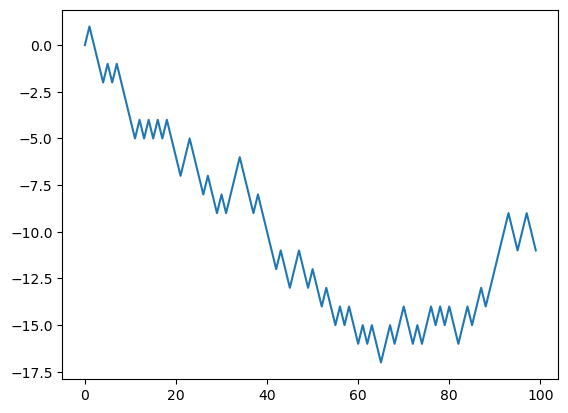

In [275]:
plt.plot(walk[:100])

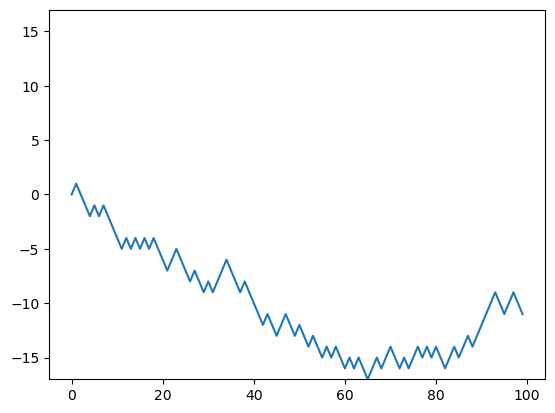

In [276]:
max_abs = max(abs(min(walk[:100])), abs(max(walk[:100])))
plt.plot(walk[:100])
plt.ylim(-max_abs, max_abs)
plt.show()

You might make the observation that walk is simply the cumulative sum of the random
steps and could be evaluated as an array expression. Thus, I use the np.random
module to draw 1,000 coin flips at once, set these to 1 and –1, and compute the
cumulative sum:

In [277]:
nsteps = 1000

In [278]:
draws = np.random.randint(0, 2, size=nsteps)  # This prints interger values between 0 and 1 , 100 times

In [279]:
draws

array([1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,

In [280]:
steps = np.where(draws > 0, 1, -1)  # this will give  1 when value is 1 ( means forwar d step) and -1 when value is 0 ( backward step)

In [281]:
steps

array([ 1,  1, -1,  1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1,  1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1,  1,  1, -1, -1,  1, -1, -1,  1,
       -1,  1, -1, -1, -1,  1,  1,  1, -1,  1,  1, -1,  1, -1,  1, -1,  1,
        1,  1,  1, -1,  1, -1,  1,  1, -1, -1,  1, -1, -1,  1,  1,  1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1, -1, -1,
       -1, -1, -1, -1, -1, -1,  1,  1,  1, -1,  1, -1, -1,  1,  1, -1,  1,
       -1,  1,  1, -1,  1, -1, -1, -1,  1,  1, -1, -1, -1, -1, -1,  1,  1,
        1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1,  1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1, -1,  1, -1,  1,  1,
       -1,  1, -1, -1,  1,  1,  1,  1, -1, -1, -1,  1, -1, -1, -1, -1, -1,
       -1, -1,  1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1, -1, -1,
        1,  1, -1, -1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1,  1,  1,  1,
       -1, -1,  1,  1,  1, -1, -1, -1,  1,  1, -1, -1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1

In [282]:
walk = steps.cumsum()  # This will tell how much he has reached : 

In [283]:
walk

array([ 1,  2,  1,  2,  1,  0, -1,  0,  1,  2,  3,  4,  3,  2,  3,  2,  1,
        0, -1, -2, -3, -4, -5, -6, -5, -6, -5, -4, -5, -6, -5, -6, -7, -6,
       -7, -6, -7, -8, -9, -8, -7, -6, -7, -6, -5, -6, -5, -6, -5, -6, -5,
       -4, -3, -2, -3, -2, -3, -2, -1, -2, -3, -2, -3, -4, -3, -2, -1, -2,
       -3, -4, -3, -2, -1,  0,  1,  2,  3,  2,  3,  2,  3,  2,  3,  2,  1,
        0, -1, -2, -3, -4, -5, -4, -3, -2, -3, -2, -3, -4, -3, -2, -3, -2,
       -3, -2, -1, -2, -1, -2, -3, -4, -3, -2, -3, -4, -5, -6, -7, -6, -5,
       -4, -3, -4, -3, -4, -3, -4, -3, -4, -3, -4, -3, -4, -3, -4, -3, -4,
       -3, -2, -1,  0, -1,  0,  1,  2,  1,  0, -1,  0, -1,  0, -1,  0,  1,
        0,  1,  0, -1,  0,  1,  2,  3,  2,  1,  0,  1,  0, -1, -2, -3, -4,
       -5, -6, -5, -6, -7, -6, -5, -6, -7, -8, -7, -8, -9, -8, -7, -8, -9,
       -8, -7, -8, -9, -8, -7, -8, -9, -8, -7, -8, -7, -8, -9, -8, -7, -6,
       -7, -8, -7, -6, -5, -6, -7, -8, -7, -6, -7, -8, -7, -6, -5, -6, -5,
       -4, -3, -2, -1,  0

From this we can begin to extract statistics like the minimum and maximum value
along the walk’s trajectory:

In [284]:
walk.min()

np.int64(-9)

In [285]:
walk.max()

np.int64(60)

A more complicated statistic is the first crossing time, the step at which the random
walk reaches a particular value. Here we might want to know how long it took the
random walk to get at least 10 (or 30) steps away from the origin 0 in either direction.
`np.abs(walk) >= 10` gives us a boolean array indicating where the walk has reached
or exceeded 10, but we want the index of the first 10 or –10. Turns out, we can compute
this using argmax, which returns the first index of the maximum value in the
boolean array (True is the maximum value):

In [286]:
np.abs(walk) >= 10

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [287]:
(np.abs(walk) >= 10).argmax()

np.int64(297)

**It is at 297th repeat he crossed 10 first time.**

Note that using argmax here is not always efficient because it always makes a full scan
of the array. In this special case, once a True is observed we know it to be the maximum
value.

#### Simulating Many Random Walks at Once

If your goal was to simulate many random walks, say 5,000 of them, you can generate
all of the random walks with minor modifications to the preceding code. If passed a
2-tuple, the `numpy.random` functions will generate a two-dimensional array of draws,
and we can compute the cumulative sum across the rows to compute all 5,000 random
walks in one shot:

In [289]:
nwalks = 5000
nsteps = 1000
draws = np.random.randint(0, 2, size=(nwalks, nsteps)) # 0 or 1
steps = np.where(draws > 0, 1, -1)

In [290]:
steps

array([[ 1,  1,  1, ...,  1,  1, -1],
       [ 1, -1,  1, ..., -1,  1,  1],
       [ 1,  1,  1, ...,  1, -1, -1],
       ...,
       [ 1, -1,  1, ..., -1,  1,  1],
       [ 1,  1, -1, ...,  1, -1, -1],
       [-1, -1, -1, ...,  1,  1,  1]], shape=(5000, 1000))

In [293]:
walks = steps.cumsum(1) # 1 here is axis. It means - go across  colums - that means do cumulative sum for row s

In [294]:
walks

array([[  1,   2,   3, ...,  46,  47,  46],
       [  1,   0,   1, ...,  40,  41,  42],
       [  1,   2,   3, ..., -26, -27, -28],
       ...,
       [  1,   0,   1, ...,  64,  65,  66],
       [  1,   2,   1, ...,   2,   1,   0],
       [ -1,  -2,  -3, ...,  32,  33,  34]], shape=(5000, 1000))

Now, we can compute the maximum and minimum values obtained over all of the
walks:


In [297]:
walks.max()

np.int64(122)

In [298]:
walks.min()

np.int64(-128)

In [299]:
np.abs(walks) >= 30

array([[False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       [False, False, False, ...,  True,  True,  True]],
      shape=(5000, 1000))

In [301]:
hits30 = (np.abs(walks) >= 30).any(1) # This will give for each walk ( row) if at least one cell is where absolute value >= 30 ( means crossed 30 steps on iotehr side) , then it will be True for that row

In [302]:
hits30

array([ True,  True,  True, ...,  True, False,  True], shape=(5000,))

In [303]:
hits30.sum() # Number that hit 30 or -30
# This many walks crossed +/- 30

np.int64(3368)

In [304]:
# We can use this boolean array to select out the rows of walks that actually cross the absolute 30 level 
# and call argmax across axis 1 to get the crossing times:
#walks[hits30] will give all walks where hits30 is true. Means Walks hit 30.
# argmax will give first value of index for the row where it reached 30. 


In [306]:
walks[hits30]

array([[  1,   2,   3, ...,  46,  47,  46],
       [  1,   0,   1, ...,  40,  41,  42],
       [  1,   2,   3, ..., -26, -27, -28],
       ...,
       [  1,   0,  -1, ..., -66, -67, -66],
       [  1,   0,   1, ...,  64,  65,  66],
       [ -1,  -2,  -3, ...,  32,  33,  34]], shape=(3368, 1000))

In [307]:
(np.abs(walks[hits30]) >= 30).argmax(1)

array([133, 395, 343, ..., 409, 297, 747], shape=(3368,))

In [308]:
crossing_times =(np.abs(walks[hits30]) >= 30).argmax(1)

In [309]:
crossing_times.mean()

np.float64(509.99762470308787)

**509.99 ~ 510 is the average number of walks it takes when simulating 5000 walks. It takes 510 walks on ana verage to cross 30!**

----

**Now same with 1,00,000 Simulations.  but 1000 steps in each walk.**
    

In [310]:
nwalks = 100000
nsteps = 1000
draws = np.random.randint(0, 2, size=(nwalks, nsteps)) # 0 or 1
steps = np.where(draws > 0, 1, -1)
walks = steps.cumsum(1)
hits30 = (np.abs(walks) >= 30).any(1)
crossing_times =(np.abs(walks[hits30]) >= 30).argmax(1)
crossing_times.mean()

np.float64(504.1556114522453)

**Now same with 1,000,000 Simulations. but 1000 steps in each walk.**

In [312]:
nwalks = 1000000
nsteps = 1000
draws = np.random.randint(0, 2, size=(nwalks, nsteps)) # 0 or 1
steps = np.where(draws > 0, 1, -1)
walks = steps.cumsum(1)
hits30 = (np.abs(walks) >= 30).any(1)
crossing_times =(np.abs(walks[hits30]) >= 30).argmax(1)
crossing_times.mean()

np.float64(503.1081129704892)

---

**Now same with 5000 Simulations. but 1000 steps in each walk. and Dsiribution of steps is my normal distribution.**

In [313]:
nwalks = 5000
nsteps = 1000

# Normal distribution controlling bias
mu = 0          # change this for drift
sigma = 1

draws = np.random.normal(mu, sigma, size=(nwalks, nsteps)) #Normal Dsitribution values will be +-
steps = np.where(draws > 0, 1, -1)

walks = steps.cumsum(axis=1)

hits30 = (np.abs(walks) >= 30).any(axis=1)
crossing_times = (np.abs(walks[hits30]) >= 30).argmax(axis=1)

print(crossing_times.mean())

497.83971714790806


In [314]:
draws

array([[-0.33560604,  0.66284776, -0.93368831, ..., -1.61160112,
        -0.69272406, -1.33246845],
       [ 0.01288087, -0.26523792, -0.15709985, ...,  0.84214912,
        -2.972156  ,  0.24711629],
       [-0.29794813, -2.01326183, -0.83726944, ...,  0.0874398 ,
        -0.25572212,  0.46640345],
       ...,
       [-1.07938002,  0.73991567,  1.8684411 , ..., -0.51564047,
        -0.6275902 , -0.30420216],
       [ 0.17733623,  0.06136108, -0.06991398, ...,  0.08080319,
         0.2206278 , -0.42428897],
       [ 0.41765204,  0.19450912,  0.00880154, ..., -0.35709484,
        -0.52971867,  1.52342234]], shape=(5000, 1000))

In [315]:
steps

array([[-1,  1, -1, ..., -1, -1, -1],
       [ 1, -1, -1, ...,  1, -1,  1],
       [-1, -1, -1, ...,  1, -1,  1],
       ...,
       [-1,  1,  1, ..., -1, -1, -1],
       [ 1,  1, -1, ...,  1,  1, -1],
       [ 1,  1,  1, ..., -1, -1,  1]], shape=(5000, 1000))